In [1]:
import requests
# import pandas as pd
import re
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# function for MIDAS Open API
def MidasAPI(method, command, body=None):
    base_url = "https://moa-engineers.midasit.com:443/gen" 
    mapi_key = "eyJ1ciI6IkFsYmVydFBhbW9uYWciLCJwZyI6ImdlbiIsImNuIjoiQldiby12dG1RQSJ9.12b57179a60ebf634b50081504bdf1a45e158893fd8306ce0b78ed5a9ef557ed"

    url = base_url + command
    headers = {
        "Content-Type": "application/json",
        "MAPI-Key": mapi_key
    }

    if method == "POST":
        response = requests.post(url=url, headers=headers, json=body)
    elif method == "PUT":
        response = requests.put(url=url, headers=headers, json=body)
    elif method == "GET":
        response = requests.get(url=url, headers=headers)
    elif method == "DELETE":
        response = requests.delete(url=url, headers=headers)

    print(method, command, response.status_code)
    return response.json()

# Unit Setting
unit_dist = "M"     # M, CM, MM, IN, FT
unit_force = "KN"   # KN, N, KGF, TONF, LBF, KIPS

file_loc = {
    "Argument": r"C:\Users\alber\Desktop\4S Apartment\midas\jawod_4s.mgbx"
}

drift_obj = {
   "Argument": {
       "TABLE_TYPE": "STORY_DRIFT_X",
       "UNIT": {
           "FORCE": "KN",
           "DIST": "MM"
       },
       "LOAD_CASE_NAMES": [
           "Ex(ST)"
       ],
       "STYLES": {
           "FORMAT": "FIXED",
           "PLACE": 5
       },
       "ADDITIONAL": {
           "SET_STORY_DRIFT_PARAMS": {
               "RESPONSE_MOD_FACTOR_CHECK": True,
               "SCALE_FACTOR_VALUE": 5.95,
               "ALLOWABLE_RATIO": 0.025,
           }
       }
   }
}

In [2]:
run = MidasAPI("POST", "/doc/ANAL", {})

POST /doc/ANAL 200


In [3]:
drift_out = MidasAPI("POST", "/post/TABLE", drift_obj)
print("DRIFT RESPONSE:", drift_out)

POST /post/TABLE 200
DRIFT RESPONSE: {'empty': {'FORCE': 'KN', 'DIST': 'MM', 'HEAD': ['Index', 'Load Case', 'Story', 'Story Height', 'P-Delta Incremental Factor', 'Allowable Story Drift Ratio', 'Maximum Drift of All Vertical Elements/Node', 'Maximum Drift of All Vertical Elements/Story Drift', 'Maximum Drift of All Vertical Elements/Modified Drift', 'Maximum Drift of All Vertical Elements/Story Drift Ratio', 'Maximum Drift of All Vertical Elements/Remark', 'Drift at the Center of Mass/Story Drift', 'Drift at the Center of Mass/Modified Drift', 'Drift at the Center of Mass/Drift Factor', 'Drift at the Center of Mass/Story Drift Ratio', 'Drift at the Center of Mass/Remark'], 'DATA': [['1', 'Ex', 'Roof Deck', '2500.00000', '1.00000', '0.02500', '1200', '5.33825', '31.76260', '0.01271', 'OK', '4.96755', '29.55690', '1.07463', '0.01182', 'OK'], ['2', 'Ex', '10F', '3000.00000', '1.00000', '0.02500', '9', '6.99201', '41.60248', '0.01387', 'OK', '6.96238', '41.42614', '1.00426', '0.01381', 'OK

C:\Users\alber\AppData\Local\Temp\ipykernel_38888\1212143953.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = pd.DataFrame(data, columns=headers).apply(pd.to_numeric, errors="ignore")


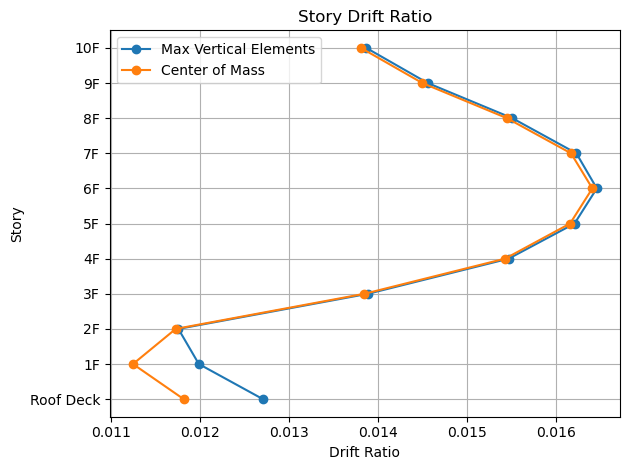

C:\Users\alber\AppData\Local\Temp\ipykernel_38888\1212143953.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")
C:\Users\alber\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [4]:



# --- Build DataFrame ---
headers = drift_out["empty"]["HEAD"]
data = drift_out["empty"]["DATA"]
df = pd.DataFrame(data, columns=headers).apply(pd.to_numeric, errors="ignore")

# --- sort stories like 1F,2F,3F,... ---
def story_no(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else 0

df["StoryNo"] = df["Story"].apply(story_no)
df = df.sort_values("StoryNo")

# --- Drift ratio columns ---
col_max_ratio = "Maximum Drift of All Vertical Elements/Story Drift Ratio"
col_com_ratio = "Drift at the Center of Mass/Story Drift Ratio"

x1 = df[col_max_ratio].abs()
x2 = df[col_com_ratio].abs()
y = df["Story"]

# --- Plot: Drift Ratio (X) vs Story (Y) ---
plt.figure()
plt.plot(x1, y, marker="o")
plt.plot(x2, y, marker="o")

plt.xlabel("Drift Ratio")
plt.ylabel("Story")
plt.title("Story Drift Ratio")

plt.grid(True)
plt.legend(["Max Vertical Elements", "Center of Mass"])
plt.tight_layout()
plt.show()

# build DataFrame
headers = drift_out["empty"]["HEAD"]
data = drift_out["empty"]["DATA"]


df = pd.DataFrame(data, columns=headers)
df = df.apply(pd.to_numeric, errors="ignore")

# --- Create Plotly Table ---
fig = go.Figure(
    data=[go.Table(
        header=dict(
            values=df.columns,
            fill_color="#E6E6E6",
            align="center",
            font=dict(size=11, color="black")
        ),
        cells=dict(
            values=[df[col] for col in df.columns],
            align="center",
            font=dict(size=10),
            height=24
        )
    )]
)

# --- Layout (important for wide MIDAS tables) ---
fig.update_layout(
    width=2600,   # increase if columns are cut
    height=400,
    margin=dict(l=10, r=10, t=10, b=10)
)

# --- Export to PNG ---
fig.write_image("Story_Drift_Table.png", scale=2)

print("PNG generated: Story_Drift_Table.png")